In [193]:
import pandas as pd
import matplotlib.pyplot as plt

URL = "http://fpaniaguapython.github.io/datos/alumnos_calificaciones_por_asignatura.csv"

df = pd.read_csv(URL, delimiter=',', encoding='utf-8')
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Alumno       6 non-null      object 
 1   Matemáticas  6 non-null      float64
 2   Lengua       4 non-null      float64
 3   Historia     6 non-null      object 
dtypes: float64(2), object(2)
memory usage: 324.0+ bytes


None

,Alumno,Matemáticas,Lengua,Historia
0,Ana García,8.5,7.0,9.0
1,Luis Martín,6.5,NaN,7.5
2,Marta López,9.0,8.5,Ocho
3,Carlos Ruiz,5.5,6.0,5.0
4,Ana García,8.5,7.0,9.0


In [194]:
# Convertimos las columnas no numéricas (Historia) a número
df['Historia'] = pd.to_numeric(df['Historia'], errors='coerce')
display(df.info())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Alumno       6 non-null      object 
 1   Matemáticas  6 non-null      float64
 2   Lengua       4 non-null      float64
 3   Historia     5 non-null      float64
dtypes: float64(3), object(1)
memory usage: 324.0+ bytes


None

,Alumno,Matemáticas,Lengua,Historia
0,Ana García,8.5,7.0,9.0
1,Luis Martín,6.5,NaN,7.5
2,Marta López,9.0,8.5,NaN
3,Carlos Ruiz,5.5,6.0,5.0
4,Ana García,8.5,7.0,9.0
5,Sofía Pérez,7.5,NaN,8.5


In [195]:
# Asignamos los Alumnos a los índices

# En un paso --> Mueve la columna Alumno al índice
df.set_index('Alumno', inplace=True)

# En dos pasos:
# 1. Copia la columna Alumno al índice
# df.set_index(df['Alumno'], inplace=True)
# 2. Elimino la columna Alumno
# df.drop('Alumno', axis=1, inplace=True)

df


,Matemáticas,Lengua,Historia
Alumno,,,
Ana García,8.5,7.0,9.0
Luis Martín,6.5,NaN,7.5
Marta López,9.0,8.5,NaN
Carlos Ruiz,5.5,6.0,5.0
Ana García,8.5,7.0,9.0
Sofía Pérez,7.5,NaN,8.5


In [196]:
# Asignamos la media a los valores faltantes
df = df.T.fillna(df.mean(axis=1)).T
display(df)

,Matemáticas,Lengua,Historia
Alumno,,,
Ana García,8.5,7.0,9.00
Luis Martín,6.5,7.0,7.50
Marta López,9.0,8.5,8.75
Carlos Ruiz,5.5,6.0,5.00
Ana García,8.5,7.0,9.00
Sofía Pérez,7.5,8.0,8.50


In [197]:
# Eliminamos los duplicados
df = df.drop_duplicates()
df

,Matemáticas,Lengua,Historia
Alumno,,,
Ana García,8.5,7.0,9.00
Luis Martín,6.5,7.0,7.50
Marta López,9.0,8.5,8.75
Carlos Ruiz,5.5,6.0,5.00
Sofía Pérez,7.5,8.0,8.50


In [198]:
# Añadimos las columnas de media, máximo y mínimo por alumno
# df_limpio = df # Se modifica el original
df_limpio = df.copy() # Se crea una copia
df_limpio['Media'] = df_limpio.mean(axis=1).round(1)
df_limpio['Máximo'] = df_limpio.max(axis=1)
df_limpio['Mínimo'] = df_limpio.min(axis=1)
df

,Matemáticas,Lengua,Historia
Alumno,,,
Ana García,8.5,7.0,9.00
Luis Martín,6.5,7.0,7.50
Marta López,9.0,8.5,8.75
Carlos Ruiz,5.5,6.0,5.00
Sofía Pérez,7.5,8.0,8.50


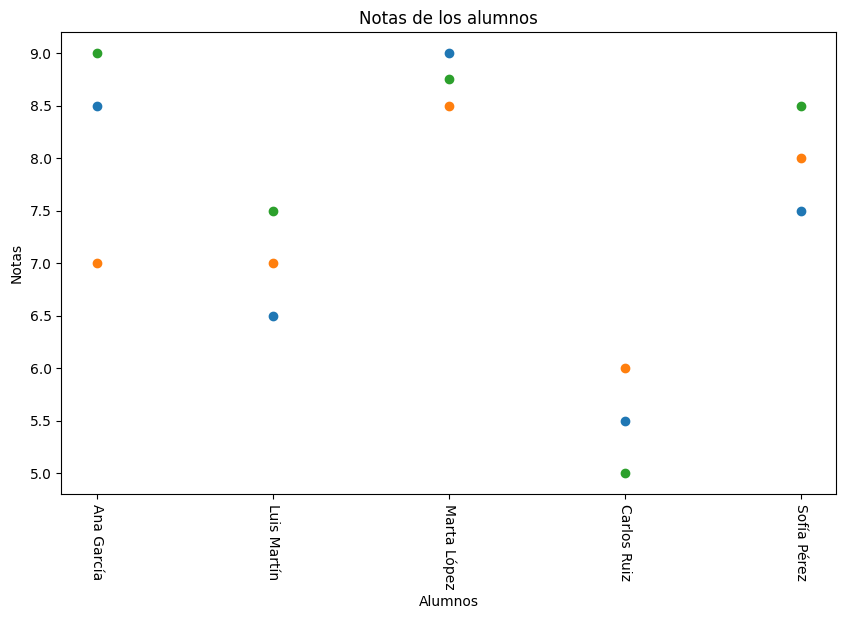

In [201]:
# Crear un diagrama de puntos con las notas de los alumnos

plt.figure(figsize=(10, 6))

plt.xticks(rotation=-90)
plt.title('Notas de los alumnos')
plt.xlabel('Alumnos')
plt.ylabel('Notas')

plt.scatter(df.index, df['Matemáticas'], label='Matemáticas')
plt.scatter(df.index, df['Lengua'], label='Lengua')
plt.scatter(df.index, df['Historia'], label='Historia')

plt.show()

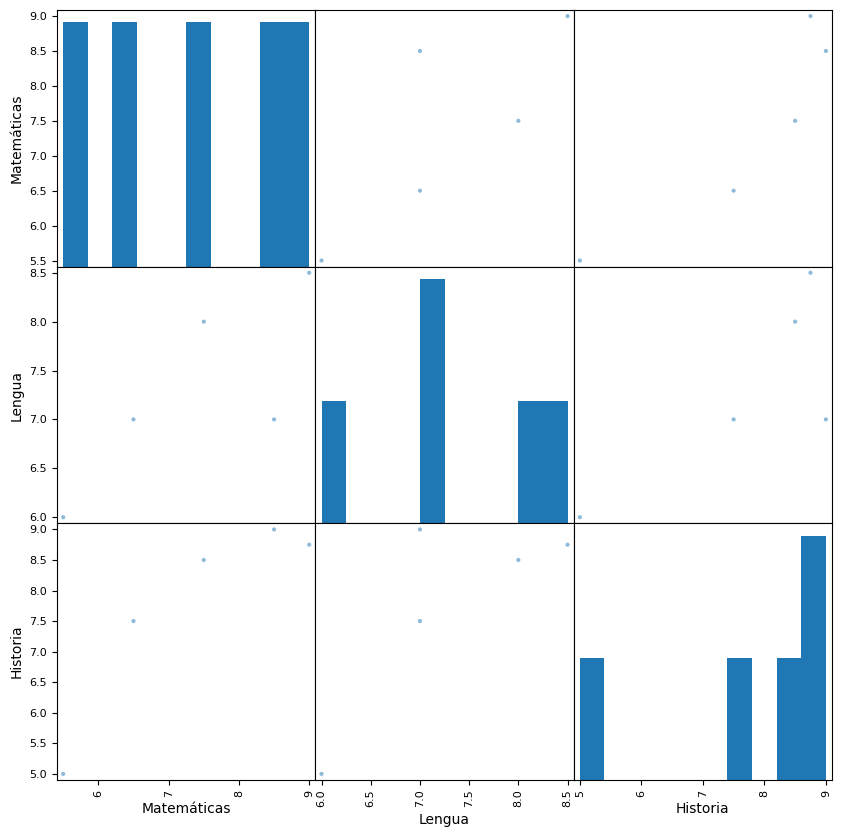

In [202]:
# Crear un diagrama directamente desde Pandas

pd.plotting.scatter_matrix(df, figsize=(10, 10))
plt.show()